Question 3

In [342]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import KFold, train_test_split


In [343]:
# Function to load dataset
directions = ["down","up","rightturn","leftturn","forward","backward","left","none"]
def load_data():

    features = []
    labels = []

    for k, direction in enumerate(directions):
        for i in range(1,81):
            try:
                df = pd.read_csv(f"../{direction}/{direction}_{i:02}.csv", usecols=['accl_x', 'accl_y', 'accl_z', 'gyro_x', 'gyro_y', 'gyro_z'])

                # Keep only accelerometer and gyroscope signals
                data = df[['accl_x', 'accl_y', 'accl_z', 'gyro_x', 'gyro_y', 'gyro_z']].values[:250].astype(np.float32)
                
                # Normalize data
                data = (data - data.min(axis=0)) / (data.max(axis=0) - data.min(axis=0))
                
                # Populate lists with normalized data and labels
                features.append(data.flatten())

                # print(data.shape)
                labels.append(direction)
            except:
                print((data.max(axis=0) - data.min(axis=0)))

    return np.array(features), np.array(labels)

In [344]:
X, Y = load_data()
# Combine data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [345]:
def classification_error(y_pred, y_test):
    res = []
    for i in range(len(y_test)):
        res.append(y_pred[i] != y_test[i])
    return np.mean(res)

### SVM


['backward' 'down' 'forward' 'left' 'leftturn' 'none' 'rightturn' 'up']
pred, actual, confidence score
down none 0.6894110158806327
backward none 0.27933785506313963
backward leftturn 0.7591904854371435
up backward 0.31080754298253477
forward none 0.4197650279276735
forward none 0.3024665905224699
backward none 0.4935504242097691
forward none 0.4024725724895685
none up 0.25997824267021435
none down 0.5217972816609812
backward forward 0.363979167487243
backward leftturn 0.26277940065852573
leftturn none 0.47871237292464774
down forward 0.8784165838160426
down forward 0.6115196438091088
rightturn none 0.49757585277579625
forward down 0.4106178187044819
forward up 0.29830046301925583
forward none 0.38475022887149074
forward none 0.5239301050924378
forward up 0.4151983154789106
up forward 0.403112719361432
down none 0.31604789286131096
none forward 0.4096493591312481
backward none 0.25178644953599
up none 0.35167872353789786
none down 0.34667718038889106
none up 0.36941519907741677
none fo

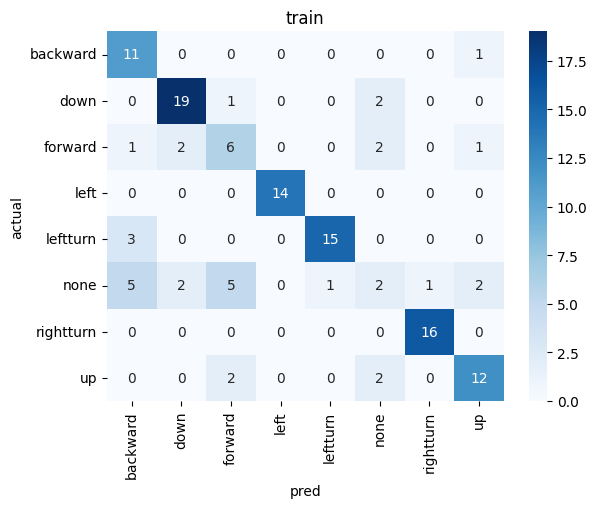

In [346]:
# def train_and_evaluate_svm(X_train, y_train, X_test, y_test):
    # Create the SVM classifier
svm_classifier = SVC(kernel='poly',C = 1, gamma=0.01, probability=True)
# Train the classifier
svm_classifier.fit(X_train, y_train)
# Perform prediction on the test set
y_pred = svm_classifier.predict(X_test)
# conf_score = svm_classifier.decision_function(X_test).argmax(axis=1)
cs = svm_classifier.predict_proba(X_test)
# y_pred = list(map(lambda x: svm_classifier.classes_[x], conf_score.tolist()))

print(svm_classifier.classes_)
print("pred, actual, confidence score")
for i in range(len(y_pred)):
    if y_pred[i] != y_test[i]:
        print(y_pred[i], y_test[i], cs[i].max())
# Evaluate the model
print(f'SVM accuracy: {accuracy_score(y_pred, y_test)*100}')

# Plot the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap="Blues", xticklabels=svm_classifier.classes_, yticklabels=svm_classifier.classes_)
plt.title('train')
plt.xlabel('pred')
plt.ylabel('actual')
plt.show()